In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Day 2 - Data Exploration

Loading the CAlifornia Housing dataset and getting a first look at it.

Goal : Understand what features the dataset has, how many rows, and whether there are any data quality issues.

In [2]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.shape

(20640, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


## Day 2 - What I Learned

1)how to import california housing dataset

2)And arranged raw data into table form for easy to readable

# About DataSet
* 20,640 rows, 9 columns
* all columns are numeric(float64)
* And No errors in dataset

# Features
* MedInc - median income
* HouseAge - average house age
* AveRooms, AveBedrms - average rooms and bedrooms
* Population, AveOccup - population data
* Latitude, Logitude- location

# Things I noticed:
* Max value is 5.0
* Income(MedInc) varies a lot - 0.5 - 5.0

Day 3 - Data Visulation

Make plots to see patterns in data . numbers tells you facts:
plots tell yiu stories


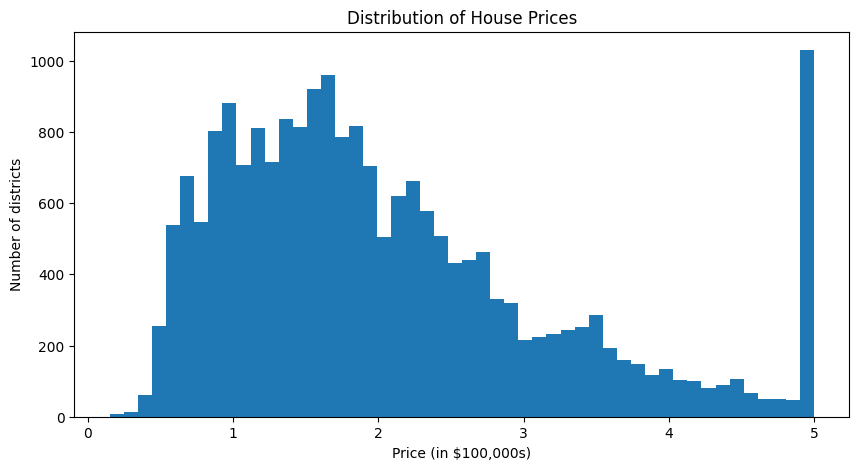

In [9]:


plt.figure(figsize=(10, 5))
plt.hist(df['Price'], bins=50)
plt.xlabel('Price (in $100,000s)')
plt.ylabel('Number of districts')
plt.title('Distribution of House Prices')
plt.show()

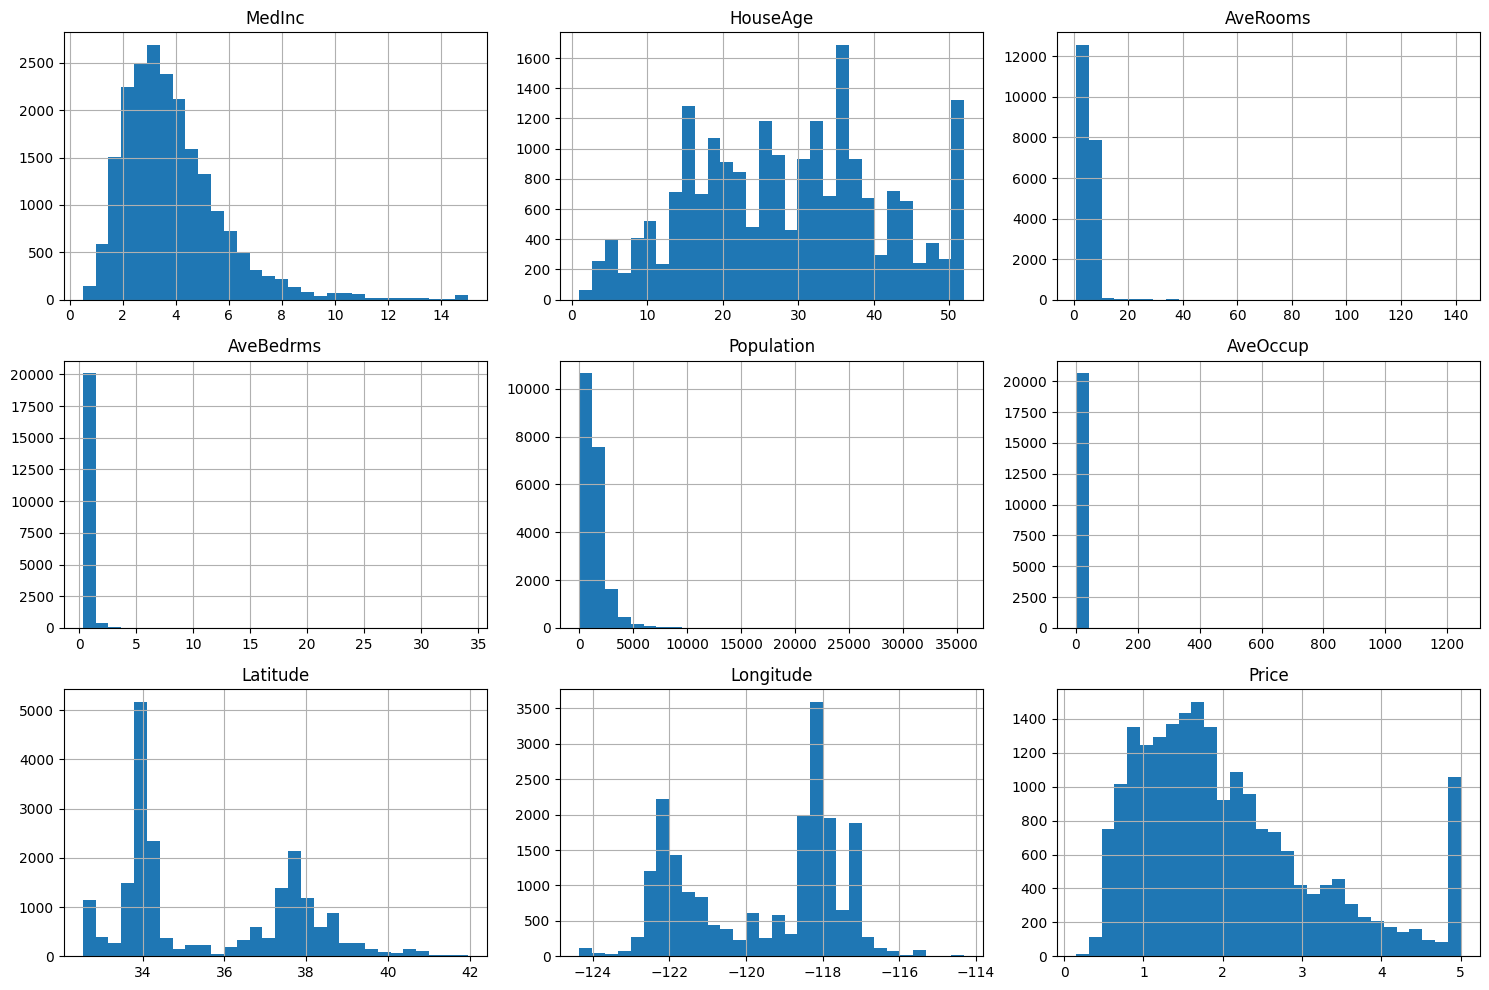

In [10]:
df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

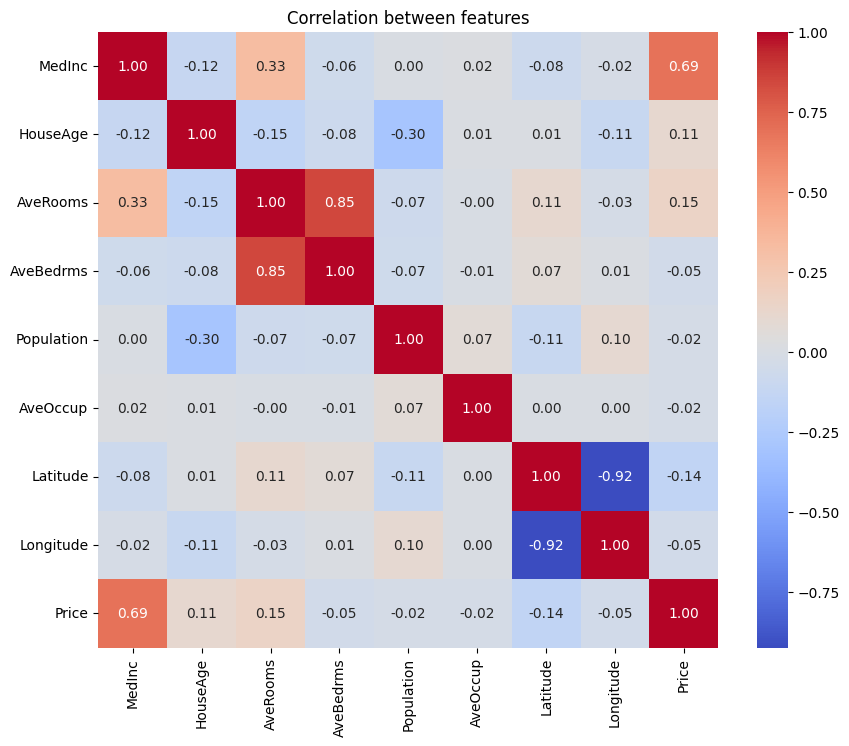

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between features')
plt.show()

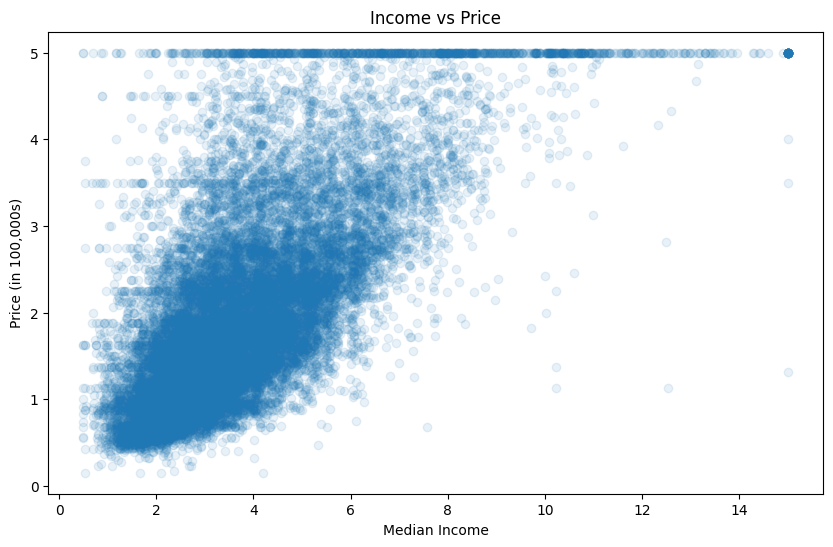

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(df['MedInc'], df['Price'], alpha=0.1)
plt.xlabel('Median Income')
plt.ylabel("Price (in 100,000s)")
plt.title('Income vs Price')
plt.show()

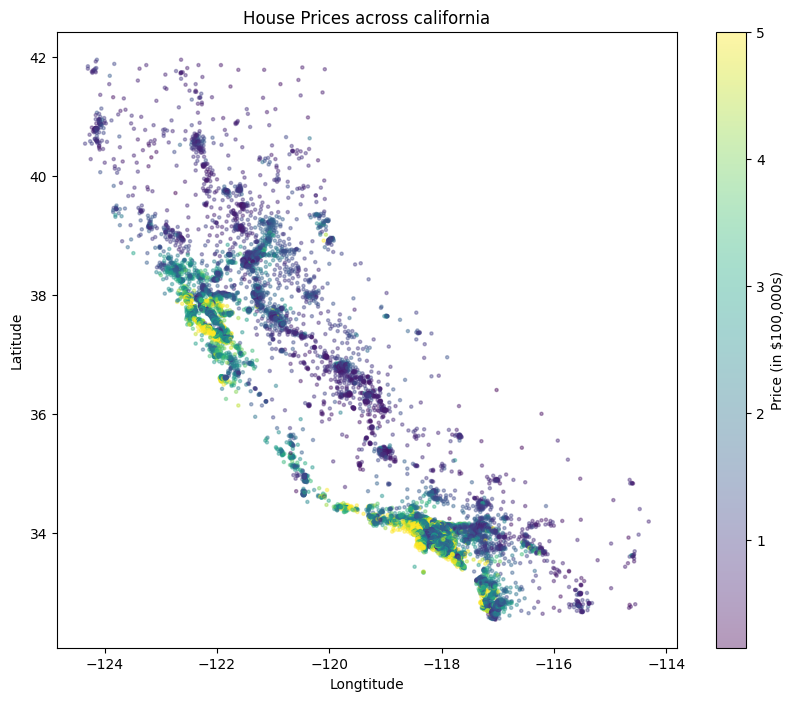

In [19]:
from scipy.__config__ import show
plt.figure(figsize=(10, 8))
plt.scatter(df['Longitude'], df['Latitude'],
            c=df['Price'], cmap='viridis', alpha=0.4, s=5)
plt.colorbar(label='Price (in $100,000s)')
plt.xlabel('Longtitude')
plt.ylabel('Latitude')
plt.title('House Prices across california')
plt.show()

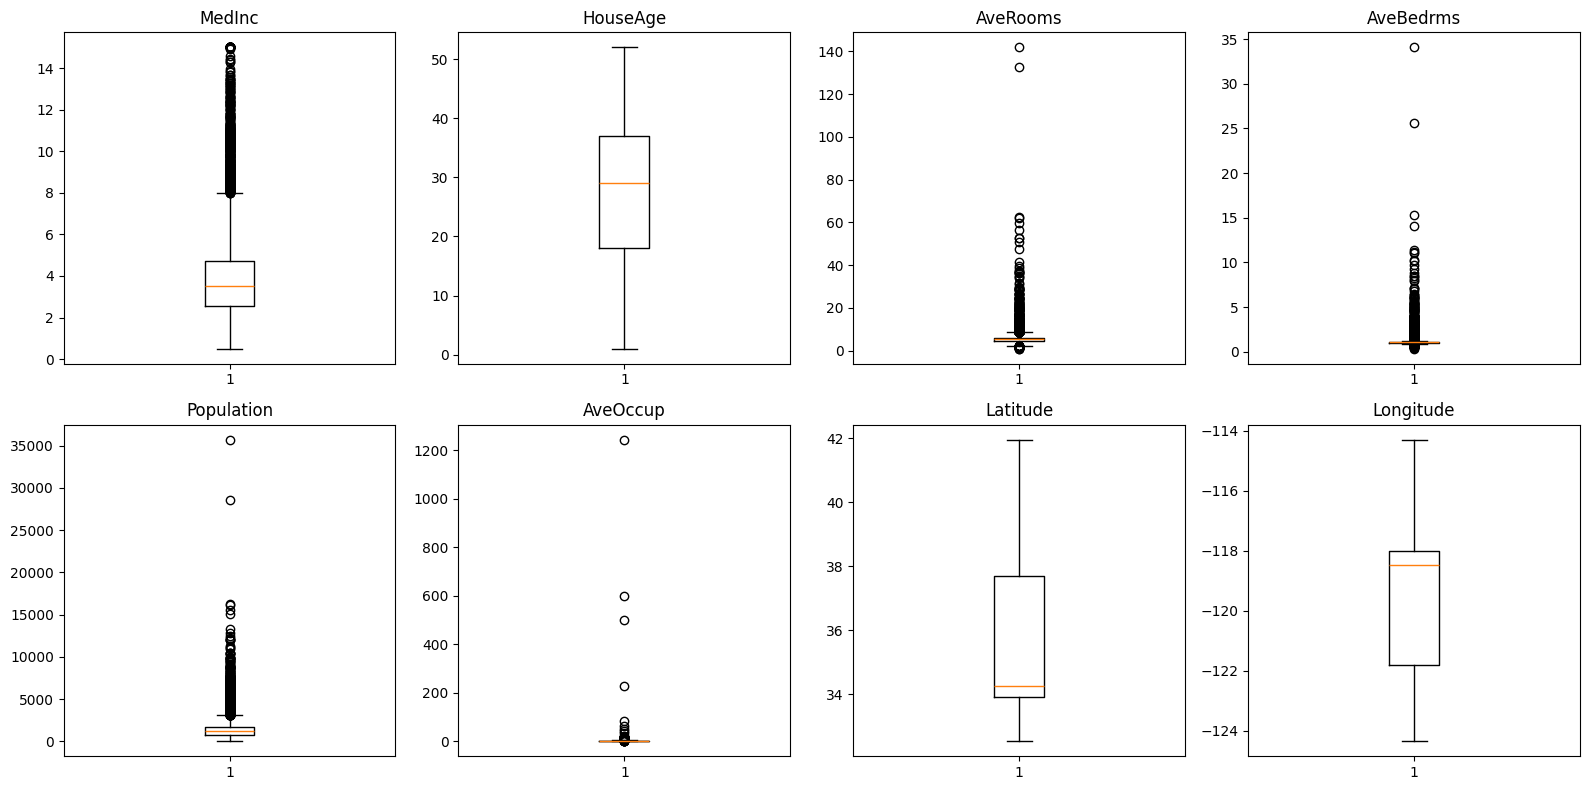

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

for i, feature in enumerate(features):
  row = i // 4
  col = i % 4
  axes[row, col].boxplot(df[feature])
  axes[row, col].set_title(feature)

plt.tight_layout()
plt.show()


## Day 3 what i have learneed from the plots

About Price:
  1. Most of the districts have price between 100k to 300k.
  2. Big spike at 500k mean too expensive but they mislabled data.
  3. My model will struggle with expensive houses

About Relationship with data (From heatmap):
  1. MedInc has the highest corrletion with price(~0.69).
  2. so Income matters more than I thought

About Geography
  1. by the Way I get to know coast are expensive
  2. inland areaas are cheaper
  3. loaction matters

About Data quality
  1. AVerooms, AveBedrooms, AveOccp have major outliers
  2. will handle later

Feature to matter:
  1. MedInc - confirmed by correlation
  2. Latitude / Longitude - Confirmed by California map



